Load Processed Dataset

In [2]:
import pandas as pd 

df = pd.read_csv("../data/processed_fraud_dataset.csv")

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 12 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   category               1296675 non-null  str    
 1   amt                    1296675 non-null  float64
 2   gender                 1296675 non-null  str    
 3   city_pop               1296675 non-null  int64  
 4   job                    1296675 non-null  str    
 5   is_fraud               1296675 non-null  int64  
 6   transaction_hour       1296675 non-null  int64  
 7   transaction_day        1296675 non-null  int64  
 8   transaction_month      1296675 non-null  int64  
 9   transaction_dayofweek  1296675 non-null  int64  
 10  age                    1296675 non-null  int64  
 11  distance_km            1296675 non-null  float64
dtypes: float64(2), int64(7), str(3)
memory usage: 118.7 MB


Separate Features and Target

In [3]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

Identify Categorical and Numerical Columns

In [4]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print(categorical_cols)
print(numerical_cols)

Index(['category', 'gender', 'job'], dtype='str')
Index(['amt', 'city_pop', 'transaction_hour', 'transaction_day',
       'transaction_month', 'transaction_dayofweek', 'age', 'distance_km'],
      dtype='str')


C:\Users\vedant\AppData\Local\Temp\ipykernel_3672\4123245944.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

Build Preprocessing Pipeline: 
We need - 1) scaling for numerical features, 2) encoding for categorical features

A - Numerical Transformer

In [6]:
from sklearn.preprocessing import StandardScaler

num_transformer = StandardScaler()

B - Categorical Transformer

In [7]:
from sklearn.preprocessing import OneHotEncoder

cat_transformer = OneHotEncoder(handle_unknown="ignore")

C - Combine using ColumnTransformer

In [8]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numerical_cols),
        ("cat", cat_transformer, categorical_cols)
    ]
)


Build Logistic Regression Pipeline

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

Train Model

In [10]:
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Predictions

In [11]:
y_pred = log_model.predict(X_test)
# Probability Predictions
y_prob = log_model.predict_proba(X_test)[:, 1]

Evaluation Metrics

Accuracy

In [12]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9940848709198526

BUT: Accuracy is misleading for fraud datasets

Precision

In [13]:
from sklearn.metrics import precision_score

precision_score(y_test, y_pred)

0.4046242774566474

Meaning: Out of predicted frauds, how many were actually fraud?

Recall

In [14]:
from sklearn.metrics import recall_score

recall_score(y_test, y_pred)

0.046635576282478344

Meaning: Out of actual frauds, how many did we catch?

F1 Score = 2*Precision*Recall/Precision+Recall

In [15]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred)

0.08363201911589008

Classification Report

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    257834
           1       0.40      0.05      0.08      1501

    accuracy                           0.99    259335
   macro avg       0.70      0.52      0.54    259335
weighted avg       0.99      0.99      0.99    259335



Confusion Matrix

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[257731    103]
 [  1431     70]]


Visualize it:

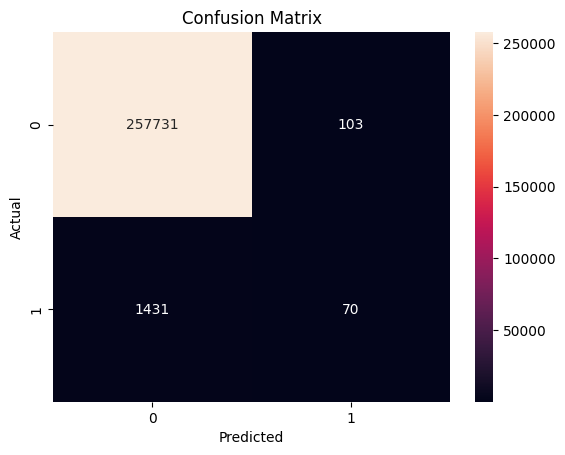

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In fraud detection, False Negatives are expensive

Missing Fraud: 1) financial Loss, 2) Security Risk

So: recall matters a lot.

ROC-AUC Score is an Important industry metric.

In [19]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8403476857068333

Higher: better class separation

Train Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier

tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier())
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

Evaluate:

In [21]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.85      0.83      0.84      1501

    accuracy                           1.00    259335
   macro avg       0.92      0.92      0.92    259335
weighted avg       1.00      1.00      1.00    259335



Train Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=20,
        max_depth=10,
        min_samples_split=50,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Evaluate:

In [23]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98    257834
           1       0.11      0.81      0.19      1501

    accuracy                           0.96    259335
   macro avg       0.55      0.88      0.58    259335
weighted avg       0.99      0.96      0.97    259335



Feature Importance - Now we start interpretability.

Get trained Ranndom Forest:

In [24]:
rf_classifier = rf_model.named_steps["classifier"]

Feature names:

In [25]:
encoded_cat_features = rf_model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_cols)

all_features = list(numerical_cols) + list(encoded_cat_features)

Feature Importance:

In [26]:
importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": rf_classifier.feature_importances_    
})

importance_df = importance_df.sort_values(
    by="importance", ascending=False
)

importance_df.head(20)

,feature,importance
0,amt,0.476175
2,transaction_hour,0.223950
14,category_home,0.046347
15,category_kids_pets,0.034989
19,category_shopping_net,0.026870
12,category_grocery_pos,0.019837
13,category_health_fitness,0.015961
6,age,0.015235
18,category_personal_care,0.013811
9,category_food_dining,0.012345


Save Models

In [27]:
import joblib

joblib.dump(rf_model, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [28]:
joblib.dump(tree_model, "../models/decision_tree.pkl")

['../models/decision_tree.pkl']

In [29]:
joblib.dump(log_model, "../models/logistic_regression.pkl")

['../models/logistic_regression.pkl']